# <center><u><b>L'analyse de performance e-commerce — TheLook Europe</b></u></center>


# <b>Contexte</b>

Vous assumez la position d'Analyste de données chez « TheLook Europe ». L'équipe du commerce électronique vous sollicite pour examiner la performance de l'activité dans un cadre spécifique et pour établir une comparaison entre l'année 2023 et l'année 2024. Votre tâche consiste à analyser les dynamiques de chiffre d'affaires, de marge, de retours et de comportement du client, puis à communiquer des conclusions claires à travers un tableau de bord Power BI.


# <b>L'objectif</b>

L'objectif de cette analyse est d'étudier les performances e-commerce du département Women en France entre 2023 et 2024.

Nous allons :

- contrôler la qualité des données,
- réaliser une analyse exploratoire,
- calculer les KPI business,
- comparer les performances 2023 vs 2024,
- identifier des recommandations business.


# <b>Le périmètre  d'étude</b>

| Paramètre | Valeur |
|---|---|
| Pays | France |
| Département | Women |
| Période | 01/01/2023 → 31/12/2024 |
| Source | `thelook_fr_women_2023_2024.csv` |
| Statut vente | `item_status = 'Complete'` |
| Statut retour | `item_status = 'Returned'` |


# <b>Les KPI à calculer</b>

| KPI | Définition |
|---|---|
| Chiffre d'affaires | `SUM(sale_price)` sur les lignes Complete |
| Marge brute | `SUM(sale_price - cost)` sur les lignes Complete |
| Panier moyen | CA / nombre de commandes distinctes (Complete) |
| Taux de retour | Returned / (Complete + Returned) × 100 |
| Taux de ré-achat | Clients avec ≥ 2 commandes Complete sur une même année / total clients actifs × 100 |


# <b>La source</b>

Fichier CSV extrait : `thelook_fr_women_2023_2024`

# 1. Configuration de l'environnement

### 1.1. Import des librairies

In [95]:
# Import des librairies avec leurs alias standard
import pandas as pd                 # Manipulation des données
import numpy as np                  # Calculs Numériques
import matplotlib.pyplot as plt     # Création des graphiques
import seaborn as sns               # Graphiques statistiques avancés

# Vérification des versions
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

# Configuration de l'affichage pandas
# display.max_columns=None   : affiche toutes les colonnes sans troncatu
# display.max_rows=100       : limite l'affichage à 100 lignes maximum
# display.precision=2        : limite l'affichage des décimales à 2 chiffres
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

Pandas version: 2.3.3
NumPy version: 2.4.4
Seaborn version: 0.13.2
Matplotlib version: 3.10.8


# 2. Importation du Dataset

### 2.1 Chargement du Dataset

In [96]:
# Import du dataset
df = pd.read_csv('/Users/ko/Documents/thelook-da-projet-soutenance/thelook-da-projet/data/thelook_fr_women_2023_2024.csv', encoding="utf-8")

# Afficher les dimensions du dataset
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")

# Afficher 5 lignes aléatoires du dataset
df.sample(5)


Dimensions du dataset : 1679 lignes x 20 colonnes


,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
1529,78849,114501,13263,2024-11-18 10:47:38+00:00,Returned,85.95,38.59,Swim,Women,L*Space,L*Space Women's Aunatural Adia Bandeau Swimsui...,Returned,2024-11-15 11:43:00+00:00,2024-11-18 03:18:00+00:00,2024-11-20 02:58:00+00:00,63082,F,France,Pays de la Loire,Angers
569,27426,39786,4136,2023-11-06 10:39:40+00:00,Shipped,129.99,70.58,Jumpsuits & Rompers,Women,VA VA VOOM,VA VA VOOM Burgundy Paisley DESIGNER Embellish...,Shipped,2023-11-03 13:05:00+00:00,2023-11-04 19:27:00+00:00,NaN,22039,F,France,Occitanie,Montpellier
121,114757,166696,1338,2023-03-22 17:12:58+00:00,Processing,48.00,20.64,Sweaters,Women,Alternative,Alternative Women's Cypress Top,Processing,2023-03-22 17:29:00+00:00,NaN,NaN,91770,F,France,Nouvelle-Aquitaine,Bordeaux
142,112668,163596,10775,2023-03-29 01:34:29+00:00,Complete,15.28,7.81,Intimates,Women,Hanes,Hanes Women's Cotton String Bikini Assorted,Complete,2023-03-26 03:23:00+00:00,2023-03-27 04:05:00+00:00,2023-03-27 08:26:00+00:00,90099,F,France,Île-de-France,Paris
158,92628,134613,14830,2023-04-05 13:52:31+00:00,Complete,16.36,7.10,Maternity,Women,Allegra K,Allegra K Maternity Pregnancy Solid Color Shor...,Complete,2023-04-05 16:53:00+00:00,2023-04-06 20:16:00+00:00,2023-04-07 04:06:00+00:00,73940,F,France,Occitanie,Bellefont-La Rauze


### 2.2 Aperçu de la structure du dataset

In [97]:
# Affichage des informations complètes du Dataset
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1679 non-null   int64  
 1   order_item_id     1679 non-null   int64  
 2   product_id        1679 non-null   int64  
 3   item_created_at   1679 non-null   object 
 4   item_status       1679 non-null   object 
 5   sale_price        1679 non-null   float64
 6   cost              1679 non-null   float64
 7   category          1679 non-null   object 
 8   department        1679 non-null   object 
 9   brand             1677 non-null   object 
 10  product_name      1679 non-null   object 
 11  order_status      1679 non-null   object 
 12  order_created_at  1679 non-null   object 
 13  shipped_at        1133 non-null   object 
 14  delivered_at      636 non-null    object 
 15  user_id           1679 non-null   int64  
 16  gender            1679 non-null   object 


In [98]:
# Statistiques descriptives des colonnes numériques
df.describe(include='all')

,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
count,1679.00,1679.00,1679.00,1679,1679,1679.00,1679.00,1679,1679,1677,1679,1679,1679,1133,636,1679.00,1679,1679,1679,1679
unique,NaN,NaN,NaN,1679,5,NaN,NaN,22,1,657,1559,5,1117,747,416,NaN,1,1,13,547
top,NaN,NaN,NaN,2023-01-01 06:18:03+00:00,Shipped,NaN,NaN,Intimates,Women,Allegra K,Shadowline Short Robe,Shipped,2023-10-09 09:00:00+00:00,2024-02-04 14:10:00+00:00,2023-10-03 22:56:00+00:00,NaN,F,France,Île-de-France,Paris
freq,NaN,NaN,NaN,1,497,NaN,NaN,247,1679,101,3,497,4,4,4,NaN,1679,1679,397,94
mean,60851.68,88372.70,7922.51,NaN,NaN,57.02,27.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48702.84,NaN,NaN,NaN,NaN
std,35655.50,51820.58,4680.55,NaN,NaN,69.68,31.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28441.85,NaN,NaN,NaN,NaN
min,359.00,517.00,12.00,NaN,NaN,1.82,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,279.00,NaN,NaN,NaN,NaN
25%,30357.00,44069.50,3812.00,NaN,NaN,19.99,9.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24349.00,NaN,NaN,NaN,NaN
50%,60827.00,88353.00,7907.00,NaN,NaN,38.00,18.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48715.00,NaN,NaN,NaN,NaN
75%,90911.00,132106.00,12053.00,NaN,NaN,68.00,33.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72541.00,NaN,NaN,NaN,NaN


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Analyse du describe :

#### Analyse de la catégorie "Intimates" :

- La catégorie *Intimates* apparaît comme la catégorie la plus représentée du dataset. Une hypothèse métier plausible est que ce type de produit bénéficie d'une fréquence d'achat plus élevée que d'autres catégories textile, notamment en raison de besoins de renouvellement réguliers.

#### Analyse des prix de vente :

- Le prix de vente moyen des produits est d'environ 57 €, tandis que la médiane est de 38 €. L'écart important entre la moyenne et la médiane suggère une distribution asymétrique à droite, probablement influencée par quelques produits à forte valeur (max observé : 903 €).

#### Analyse des coûts produits :

- Le coût moyen (~27 €) reste inférieur au prix moyen de vente (~57 €). Cette structure est cohérente avec un modèle économique e-commerce reposant sur une marge commerciale positive.

#### Analyse des statuts de commande :

- Le dataset contient 5 statuts différents. Il sera important de bien définir les statuts utilisés dans les KPI : **"Complete"** pour les ventes finalisées, **"Returned"** pour les retours produits.

#### Analyse des valeurs manquantes :

- Les colonnes `shipped_at` et `delivered_at` présentent un volume important de valeurs manquantes. Ces absences sont cohérentes avec le cycle opérationnel des commandes (annulées, retournées, en cours).
</details>

### 2.3 Dictionnaire des données

Le dictionnaire de données permet de comprendre rapidement le rôle de chaque colonne, vérifier les types de données et faciliter la lecture du projet. C'est une bonne pratique pour documenter et sécuriser l'analyse.

| Colonne | Type | Description | Exemple |
|---|---|---|---|
| order_id | int64 | Identifiant de commande | 19425 |
| order_item_id | int64 | Identifiant unique de ligne produit | 28112 |
| product_id | int64 | Identifiant produit | 6983 |
| item_created_at | datetime | Date de création de la ligne produit | 2023-01-01 06:18:03 |
| item_status | object | Statut de la ligne produit | Complete |
| sale_price | float64 | Prix de vente TTC du produit | 29.50 |
| cost | float64 | Coût du produit | 16.05 |
| category | object | Catégorie produit | Shorts |
| department | object | Département produit | Women |
| brand | object | Marque produit | Fox |
| product_name | object | Nom du produit | Fox Juniors Momentum Short |
| order_status | object | Statut global de la commande | Shipped |
| order_created_at | datetime | Date de création de la commande | 2023-01-03 |
| shipped_at | datetime | Date d'expédition | 2023-01-05 |
| delivered_at | datetime | Date de livraison | 2023-01-09 |
| user_id | int64 | Identifiant client | 15644 |
| gender | object | Genre du client | F |
| country | object | Pays du client | France |
| state | object | Région du client | Île-de-France |
| city | object | Ville du client | Paris |

# 3. Contrôle de qualité des données

### 3.1 Création d'une copie de travail du dataset

In [99]:
'''
Création d'une copie du dataset original.
Cela permet de conserver les données brutes intactes en cas d'erreur
pendant le nettoyage ou les transformations.
On travaillera uniquement sur cette copie pour sécuriser l'analyse.
'''

# Création de la copie du dataset
df_clean = df.copy()

print("Copie créée avec succès.")
print(f"Dimensions : {df_clean.shape[0]} lignes x {df_clean.shape[1]} colonnes")

Copie créée avec succès.
Dimensions : 1679 lignes x 20 colonnes


### 3.2 Traitement des valeurs manquantes

In [100]:
# Nombre de valeurs manquantes par colonne
nbr_nan = df_clean.isna().sum()

# Affichage
nbr_nan

order_id               0
order_item_id          0
product_id             0
item_created_at        0
item_status            0
sale_price             0
cost                   0
category               0
department             0
brand                  2
product_name           0
order_status           0
order_created_at       0
shipped_at           546
delivered_at        1043
user_id                0
gender                 0
country                0
state                  0
city                   0
dtype: int64

In [101]:
# Pourcentage de valeurs manquantes par colonne
pourcent_nan = (df_clean.isna().sum() / len(df_clean)) * 100 

# Affichage 
pourcent_nan

order_id             0.00
order_item_id        0.00
product_id           0.00
item_created_at      0.00
item_status          0.00
sale_price           0.00
cost                 0.00
category             0.00
department           0.00
brand                0.12
product_name         0.00
order_status         0.00
order_created_at     0.00
shipped_at          32.52
delivered_at        62.12
user_id              0.00
gender               0.00
country              0.00
state                0.00
city                 0.00
dtype: float64

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- La majorité des colonnes ne présentent aucune valeur manquante.
- Les variables liées au cycle de commande **`shipped_at` (32.52%)** et **`delivered_at` (62.12%)** affichent un taux de valeurs manquantes élevé.
- La colonne **`brand`** présente très peu de valeurs manquantes (0.12%).
- Les autres variables (produit, client, localisation, prix) sont complètes.

### Interprétation :

- Les valeurs manquantes sur les dates d’expédition et de livraison sont cohérentes avec le cycle de vie des commandes :
  * commandes annulées,
  * commandes retournées,
  * ou commandes non encore expédiées.
- Ces valeurs ne traduisent pas une erreur de données mais une réalité métier du e-commerce.
- La faible proportion de valeurs manquantes sur `brand` peut être liée à des produits non référencés ou mal renseignés.

### Conclusion :

- Aucune suppression de données n’est effectuée sur les colonnes liées au cycle de commande afin de préserver l’intégrité métier.
- La variable `brand` sera imputée avec la valeur **"Unknown"** pour garantir la continuité des analyses.
- Ces choix assurent des KPI cohérents et exploitables pour le dashboard et les analyses suivantes.

</details>

#### 3.2.1 Imputation des valeurs manquants pour la colonne brand

In [102]:
# Imputation des valeurs manquantes par "Unknown" pour la colonne brand
# Cela permet de conserver les lignes concernées dans les analyses
# tout en gardant une catégorie identifiable
df_clean['brand'] = df_clean['brand'].fillna('Unknown')

# Vérification : plus aucune valeur manquante dans brand
print(f"Valeurs manquantes dans brand : {df_clean['brand'].isna().sum()}")

Valeurs manquantes dans brand : 0


#### 3.2.2 Vérification de la colonne item_status

In [103]:
# Affichage des statuts uniques des lignes produits
df_clean['item_status'].unique()

array(['Shipped', 'Complete', 'Processing', 'Returned', 'Cancelled'],
      dtype=object)

In [104]:
# Pourcentage des statuts
df_clean['item_status'].value_counts(normalize=True) * 100

item_status
Shipped       29.60
Complete      25.31
Processing    18.23
Cancelled     14.29
Returned      12.57
Name: proportion, dtype: float64

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- Cinq statuts de commande sont présents dans le dataset.
- Les statuts les plus fréquents sont **Shipped (29.60%)** et **Complete (25.31%)**, représentant plus de la moitié des commandes.
- Une part significative des commandes est encore en cours de traitement (**Processing : 18.23%**).
- Les commandes annulées (**Cancelled : 14.29%**) et retournées (**Returned : 12.57%**) représentent une part non négligeable de l’activité.

### Interprétation :

- Le pipeline de commande montre une activité globale saine, avec une majorité de commandes allant jusqu’à l’expédition ou la complétion.
- Le niveau de **Cancelled + Returned (~27%)** peut indiquer un enjeu potentiel sur la qualité produit, le parcours client ou les attentes clients.
- La présence de commandes encore en **Processing** est normale mais doit être surveillée si elle augmente dans le temps.

### Conclusion :

- Pour l’analyse des KPI, la convention retenue est :
  * **Ventes = Complete**
  * **Retours = Returned**
- Cette définition permet de garantir des KPI cohérents et comparables dans le temps.
- Une analyse complémentaire sur les causes des annulations et retours pourrait aider à améliorer la performance commerciale.

</details>

#### 3.2.3 Vérification de la colonne shipped_at et de la colonne delivered_at

In [105]:
# Vérifier les statuts associés aux valeurs manquantes de shipped_at
print("Statuts pour les valeurs manquantes de shipped_at")
print(df_clean[df_clean['shipped_at'].isna()]['order_status'].value_counts())

print()

# Vérifier les statuts associés aux valeurs manquantes de delivered_at
print("Statuts pour les valeurs manquantes de delivered_at")
print(df_clean[df_clean['delivered_at'].isna()]['order_status'].value_counts())

Statuts pour les valeurs manquantes de shipped_at
order_status
Processing    306
Cancelled     240
Name: count, dtype: int64

Statuts pour les valeurs manquantes de delivered_at
order_status
Shipped       497
Processing    306
Cancelled     240
Name: count, dtype: int64


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

#### Valeurs manquantes de `shipped_at`:

- Les valeurs manquantes sont principalement associées aux statuts **Processing (306)** et **Cancelled (240)**.
- Cela représente des commandes qui n’ont pas encore été expédiées ou qui ont été annulées.

#### Valeurs manquantes de `delivered_at`: 

- Les valeurs manquantes concernent les statuts **Shipped (497)**, **Processing (306)** et **Cancelled (240)**.
- Ces commandes ne sont pas encore livrées ou ne seront jamais livrées dans le cas des commandes annulées.

### Interprétation :

- Les valeurs manquantes sont directement liées au cycle de vie des commandes :
  * **Processing** → commande en cours de traitement
  * **Shipped** → commande expédiée mais pas encore livrée
  * **Cancelled** → commande annulée donc non livrée
- Les valeurs manquantes sont donc **structurelles et attendues**, et non dues à une erreur de données.

### Conclusion =

- Ces valeurs manquantes sont conservées car elles traduisent la réalité métier du processus e-commerce.
- Elles permettent d’analyser correctement les étapes du parcours client (préparation, expédition, livraison, annulation).
- Aucun traitement de suppression n’est nécessaire afin de préserver la cohérence des KPI logistiques.

</details>

### 3.3 Traitement des doublons

#### 3.3.1 Identification des vrais doublons

In [106]:
''' 
Comme nous l'avons vu dans le cours, la méthode duplicated() permet d'identifier les doublons. 
Nous avons obtenu comme résultat que toutes les lignes ont la valeur False, ce peut signifier qu'il n'y a pas de doublon 
et que les lignes du jeu de donnée fournis ne sont pas dupliqué sur l'ensemble des colonnes.
'''

# Comptage des lignes intégralement dupliquées
nombre_doublons = df_clean.duplicated().sum()
print(f"Il y a {nombre_doublons} ligne(s) intégralement dupliquée(s)")

Il y a 0 ligne(s) intégralement dupliquée(s)


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- Aucun doublon intégral n’est présent dans le dataset.
- Chaque ligne correspond à une ligne de commande unique.

### Interprétation :

- L’absence de doublons indique une bonne structuration des données au niveau transactionnel.
- Cela signifie que les clés de jointure et la granularité des données sont correctement définies (niveau ligne de commande).

### Conclusion :

- Le dataset est fiable sur le plan des doublons.
- Cette qualité de donnée permet de construire des KPI robustes sans risque de surcomptage des ventes.

</details>

#### 3.3.2 Traitement des faux doublons

In [107]:
'''
Test sur la colonne order_item_id
'''

# Vérification : order_item_id doit être unique (identifiant de ligne produit)
doublons_item_id = df_clean.duplicated(subset=['order_item_id']).sum()
print(f"Doublons sur order_item_id : {doublons_item_id}")

Doublons sur order_item_id : 0


In [108]:
'''
Test sur les colonnes order_id et product_id
'''

# Vérification : un même produit ne doit pas apparaître deux fois dans la même commande
doublons_order_product = df_clean.duplicated(subset=['order_id', 'product_id']).sum()
print(f"Doublons sur order_id & product_id : {doublons_order_product}")

Doublons sur order_id & product_id : 0


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- Aucun doublon sur `order_item_id` : chaque ligne de commande est unique.

- Aucun doublon sur `order_id + product_id` : chaque produit n'apparaît qu'une seule fois par commande.

- L'intégrité des données est confirmée. Les KPI (CA, marge, taux de retour) seront calculés sur des données fiables.
</details>

# 4. Conversion des données

### 4.1 Conversion des dates


In [109]:
'''  
Conversion des colonnes au format datetime
Cela permet à Python de reconnaître les colonnes comme des dates
pour pouvoir faire des analyses temporelles (année, mois ou les délais par exemple)
'''

#  Conversion des colonnes au format datetime
df_clean['item_created_at'] = pd.to_datetime(df_clean['item_created_at'])
df_clean['order_created_at'] = pd.to_datetime(df_clean['order_created_at'])
df_clean['shipped_at'] = pd.to_datetime(df_clean['shipped_at'])
df_clean['delivered_at'] = pd.to_datetime(df_clean['delivered_at'])

# Vérification des types de données
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   order_id          1679 non-null   int64              
 1   order_item_id     1679 non-null   int64              
 2   product_id        1679 non-null   int64              
 3   item_created_at   1679 non-null   datetime64[ns, UTC]
 4   item_status       1679 non-null   object             
 5   sale_price        1679 non-null   float64            
 6   cost              1679 non-null   float64            
 7   category          1679 non-null   object             
 8   department        1679 non-null   object             
 9   brand             1679 non-null   object             
 10  product_name      1679 non-null   object             
 11  order_status      1679 non-null   object             
 12  order_created_at  1679 non-null   datetime64[ns, UTC]
 13  shi

### 4.2 Création des variables temporelles

In [110]:
# Création des colonnes year et month à partir de item_created_at
# Cela simplifiera toutes les analyses temporelles qui suivent
df_clean['year']  = df_clean['item_created_at'].dt.year
df_clean['month'] = df_clean['item_created_at'].dt.month

# Affichage de 5 lignes aléatoires pour vérification
df_clean.sample(5)

,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city,year,month
1634,3712,5302,15750,2024-12-17 22:43:10+00:00,Cancelled,91.85,45.01,Plus,Women,Kate Spade,Kate Spade Women's Lulu Gradient Rectangle Sun...,Cancelled,2024-12-14 00:56:00+00:00,NaT,NaT,3055,F,France,Île-de-France,Coupvray,2024,12
197,47155,68544,10690,2023-04-22 13:49:40+00:00,Processing,4.95,2.61,Intimates,Women,FineBrandShop,Seamless Bandeau Strapless Tube Top Bra Black,Processing,2023-04-22 14:56:00+00:00,NaT,NaT,37850,F,France,Île-de-France,Le Blanc-Mesnil,2023,4
1012,46432,67473,13054,2024-05-25 12:28:34+00:00,Shipped,148.00,62.01,Swim,Women,Trina Turk,Trina Turk Women's Yukateca Bandeau One Pc,Shipped,2024-05-25 14:50:00+00:00,2024-05-25 21:00:00+00:00,NaT,37272,F,France,Auvergne-Rhône-Alpes,Saint-Symphorien-d'Ozon,2024,5
453,359,518,14956,2023-09-08 00:09:06+00:00,Cancelled,44.00,20.28,Maternity,Women,Melinda G,Melinda G Tee-Shirt Soft-Cup Nursing Bra,Cancelled,2023-09-05 00:45:00+00:00,NaT,NaT,279,F,France,Hauts-de-France,Villers-Cotterêts,2023,9
104,60827,88353,1081,2023-03-05 15:01:45+00:00,Complete,119.00,54.86,Sweaters,Women,Woolrich,Woolrich Women's Mountainside Cardigan,Complete,2023-03-05 18:50:00+00:00,2023-03-06 18:57:00+00:00,2023-03-09 07:12:00+00:00,48715,F,France,Occitanie,Castelnau-de-Lévis,2023,3


### 4.3 Vérification de la période temporelle

In [111]:
'''
On s'assure que toutes les dates sont bien dans la période 2023-2024
L'énoncé demande explicitement cette vérification.
'''

# Vérification des bornes temporelles
print(f"Date minimum : {df_clean['item_created_at'].min()}")
print(f"Date maximum : {df_clean['item_created_at'].max()}")
print()
print("Les données doivent couvrir du 01/01/2023 au 31/12/2024")

Date minimum : 2023-01-01 06:18:03+00:00
Date maximum : 2024-12-31 10:40:48+00:00

Les données doivent couvrir du 01/01/2023 au 31/12/2024


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- Les données couvrent bien la période demandée : du 01/01/2023 au 31/12/2024.

- Cette étape garantit la cohérence du sous-périmètre d'analyse demandé par la direction e-commerce.
</details>

### 4.4  Définition du périmètre ventes

In [112]:
# Convention du projet : item_status == "Complete" = vente finalisée
# On crée df_sales une seule fois ici pour éviter les redéfinitions
# dans les sections suivantes

# Filtre des ventes complètes
df_sales = df_clean[df_clean['item_status'] == 'Complete'].copy()

# Afficher les dimensions du dataset filtré
print(f"Dimensions du dataset ventes : {df_sales.shape[0]} lignes x {df_sales.shape[1]} colonnes")

# Affichage de 5 lignes aléatoires
df_sales.sample(5)

Dimensions du dataset ventes : 425 lignes x 22 colonnes


,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city,year,month
590,50275,73086,14688,2023-11-19 10:54:50+00:00,Complete,49.98,20.64,Maternity,Women,Motherhood Maternity,Motherhood Maternity: 1 Button Closure Fleece ...,Complete,2023-11-18 12:32:00+00:00,2023-11-21 02:01:00+00:00,2023-11-22 02:04:00+00:00,40338,F,France,Auvergne-Rhône-Alpes,Izeaux,2023,11
1303,100612,146124,3763,2024-09-04 03:19:28+00:00,Complete,13.79,6.80,Dresses,Women,Allegra K,Allegra K Woman Sleeveless U Neck Low-high Coa...,Complete,2024-09-04 03:18:00+00:00,2024-09-06 17:00:00+00:00,2024-09-08 16:38:00+00:00,80375,F,France,Normandie,Montivilliers,2024,9
573,58036,84352,2078,2023-11-08 11:32:47+00:00,Complete,35.99,16.81,Fashion Hoodies & Sweatshirts,Women,Hurley,Hurley Juniors Vacay Crew YC Fleece Hoodie,Complete,2023-11-08 14:17:00+00:00,2023-11-09 15:57:00+00:00,2023-11-14 09:52:00+00:00,46470,F,France,Pays de la Loire,Le Mans,2023,11
868,102022,148240,15170,2024-03-19 05:37:27+00:00,Complete,59.50,28.20,Maternity,Women,A Pea in the Pod,A Pea in the Pod: Long Sleeve Split Neck Super...,Complete,2024-03-18 09:00:00+00:00,2024-03-20 12:37:00+00:00,2024-03-24 18:18:00+00:00,81512,F,France,Île-de-France,Cergy,2024,3
1300,121486,176516,404,2024-09-03 12:54:47+00:00,Complete,13.37,7.54,Tops & Tees,Women,Allegra K,Allegra K Woman Gray Boat Neck Bating Long Sle...,Complete,2024-09-03 15:32:00+00:00,2024-09-04 10:59:00+00:00,2024-09-07 13:30:00+00:00,97119,F,France,Hauts-de-France,Hirson,2024,9


# 5. Analyse Exploratoire (EDA)

### 5.1 Distribution du prix de vente

#### 5.1.1 Statistiques descriptives

In [113]:
# Statistiques descriptives du prix de vente 
# On utilise df_sales : uniquement les ventes finalisées
df_sales["sale_price"].describe()

count    425.00
mean      55.35
std       71.41
min        1.82
25%       18.97
50%       36.29
75%       62.36
max      903.00
Name: sale_price, dtype: float64

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- Le prix de vente moyen est de **55,35 €**, avec une médiane plus basse à **36,29 €**, ce qui indique une distribution asymétrique.
- La majorité des produits se situe dans une gamme de prix relativement accessible (25% des produits à moins de 18,97 €).
- On observe une forte dispersion des prix, avec un écart important entre les produits les moins chers (**1,82 €**) et les plus chers (**903 €**).
- La présence d’un maximum élevé tire la moyenne vers le haut.

### Interprétation :

- La différence entre la moyenne et la médiane confirme une **distribution asymétrique à droite**, typique des catalogues e-commerce.
- Le catalogue semble composé majoritairement de produits accessibles, complété par une sélection de produits premium à forte valeur ajoutée.
- Les produits haut de gamme influencent fortement les indicateurs globaux comme la moyenne de prix.

### Conclusion :

- Le catalogue présente un positionnement **multi-segments**, combinant une offre grand public et une offre premium.
- Cette structure explique la coexistence de volumes élevés sur certaines catégories et de fortes contributions en chiffre d’affaires sur des produits à prix élevé.

</details>

#### 5.1.2 Graphe Distribution du prix 

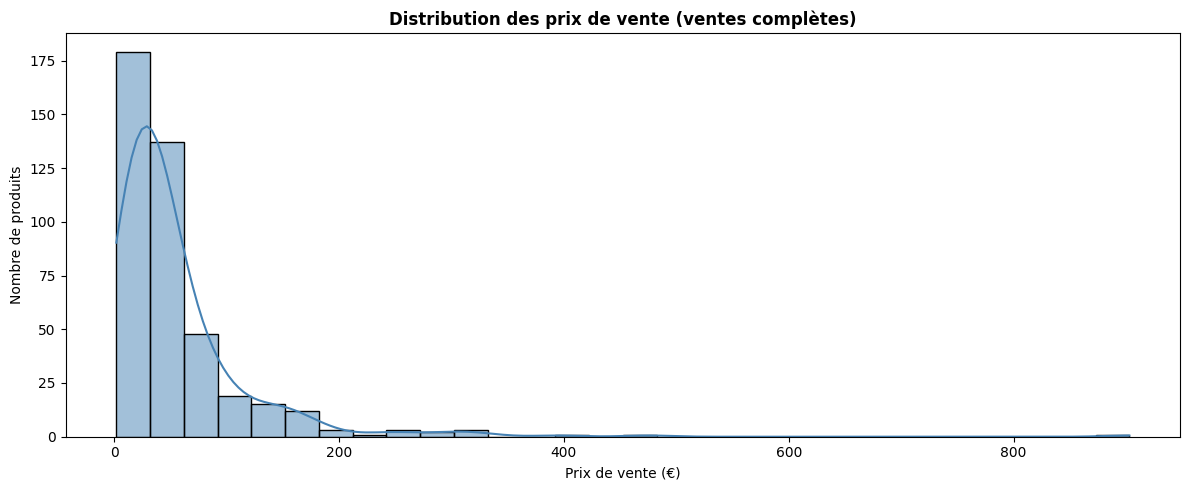

In [114]:
# Taille du graphique
plt.figure(figsize=(12, 5))

# Création de l'histogramme avec courbe de densité
sns.histplot(
    data=df_sales,
    x="sale_price",
    bins=30,
    kde=True,
    color="steelblue"
)

# Ajour du titre
plt.title("Distribution des prix de vente (ventes complètes)", fontsize=12, fontweight='bold')

# Ajout des labels des axes
plt.xlabel("Prix de vente (€)")
plt.ylabel("Nombre de produits")

# Mise en page automatique
plt.tight_layout()

# Affichage du graphe
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations

- La distribution des prix de vente est fortement asymétrique à droite.
- La majorité des produits se situe dans une gamme de prix comprise entre **0 € et 60 €**.
- Une longue traîne est visible vers les prix élevés, avec un maximum observé à **903 €**.
- La moyenne des prix (~57 €) est supérieure à la médiane (~38 €).
- L’écart entre moyenne et médiane indique une forte influence des valeurs élevées sur la moyenne.

### Interprétation

- Le catalogue est principalement composé de produits à prix accessibles, ce qui explique la concentration des ventes dans les faibles valeurs.
- La présence de produits premium crée une dispersion importante et tire la moyenne vers le haut.
- La médiane est plus représentative du prix “typique” d’un produit vendu dans ce dataset.
- Cette structure est typique d’un catalogue e-commerce multi-segments (entrée de gamme + premium).

### Conclusion

- Le comportement des prix confirme une stratégie de catalogue mixte : majorité de produits accessibles et minorité de produits premium.
- La distribution étant asymétrique, la médiane est un indicateur plus fiable que la moyenne pour représenter le prix standard des produits.
- Cette structure explique la coexistence de volumes de ventes élevés sur certains segments et de fortes contributions au chiffre d’affaires sur d’autres.

</details>

### 5.2 Distribution du coût produit

#### 5.2.1 Statistiques descriptives

In [115]:
# Statistiques descriptives du coût
df_sales["cost"].describe()

count    425.00
mean      26.62
std       33.70
min        0.75
25%        8.74
50%       17.97
75%       29.58
max      437.05
Name: cost, dtype: float64

#### 5.2.2 Détection des valeurs aberrantes sur les coûts

In [116]:
# Calcul des quartiles Q1 et Q3
Q1 = df_sales["cost"].quantile(0.25)
Q3 = df_sales["cost"].quantile(0.75)

# Calcul de l'écart interquartile (IQR)
IQR = Q3 - Q1

# Définition des bornes hautes et basses
limite_inferieure = Q1 - 1.5 * IQR
limite_superieure = Q3 + 1.5 * IQR

# Détection des valeurs aberrantes
masque_outliers = (
    (df_sales["cost"] < limite_inferieure) |
    (df_sales["cost"] > limite_superieure)
)

# Extraction des outliers
outliers = df_sales.loc[masque_outliers]

# Affichage du nombre d'outliers
print(f"Nombre d'outliers détectés : {len(outliers)}")

# Affichage des 10 produits avec les coûts les plus élevés
outliers[[
    "product_name",
    "brand",
    "category",
    "sale_price",
    "cost"
]].sort_values(by="cost", ascending=False).head(10)

Nombre d'outliers détectés : 41


,product_name,brand,category,sale_price,cost
468,The North Face Denali Down Womens Jacket 2013,The North Face,Outerwear & Coats,903.00,437.05
1442,Arc'teryx Women's Beta AR Jacket,Arc'teryx,Outerwear & Coats,475.00,205.20
509,Rebecca Taylor Women's Lace Dress,Rebecca Taylor,Dresses,395.00,179.33
1097,BGSD Women's New Zealand Lambskin Leather Walk...,BGSD,Outerwear & Coats,319.99,144.64
429,Women's The North Face Half Dome Hoodie Sweats...,The North Face,Active,308.00,144.45
1646,True Religion Women's Tony Pony Express Slim Jean,True Religion,Jeans,235.00,132.54
880,Jones New York Walker Leather Jacket,Jones New York,Outerwear & Coats,299.99,127.80
1053,McGinn Women's Clara Textured Blazer,McGinn,Blazers & Jackets,330.00,126.72
679,Trina Turk Women's Elizabeth Toggle Coat,Trina Turk,Outerwear & Coats,290.28,119.60
1260,Pendleton The Portland Collection Women's Coos...,Pendleton,Sweaters,264.67,112.75


### 5.2.3 Graphique de distribution des coûts

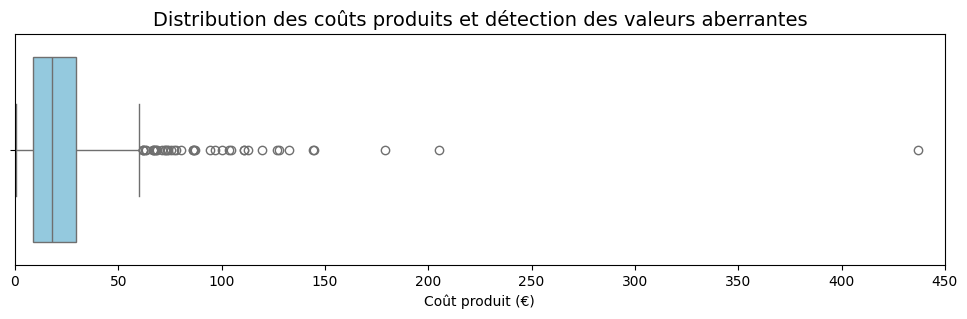

In [117]:
# Création de la taille de la figure 
plt.figure(figsize=(12,3))

# Création du graphique
sns.boxplot(
    data=df_sales,
    x="cost",
    color="skyblue"
)

# Ajout du titre
plt.title(
    "Distribution des coûts produits et détection des valeurs aberrantes",
    fontsize=14,
)

# Zoom sur les valeurs principales
plt.xlim(0, 450)

# Ajout du Label des axes
plt.xlabel("Coût produit (€)")

# Affichage du graphique
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- La distribution des coûts est fortement concentrée sur les faibles montants.
- Plusieurs valeurs extrêmes apparaissent dans la partie supérieure de la distribution.
- Le boxplot met en évidence une forte dispersion des coûts pour certains produits.

### Interprétation :

- Ces valeurs élevées correspondent probablement à des produits premium ou à forte valeur ajoutée.
- La présence d'outliers semble cohérente avec la diversité du catalogue e-commerce et ne traduit pas nécessairement une erreur de données.
- Ces produits peuvent avoir une influence importante sur les analyses de chiffre d'affaires et de marge.

### Conclusion :

- Les valeurs atypiques sont conservées car elles reflètent une réalité métier.
- Aucun traitement des outliers n'est appliqué à ce stade afin de préserver l'information économique portée par les produits les plus coûteux.

</details>

### 5.3 Contribution des marques 

#### 5.3.1 Calcul du CA par marque (Top 10)

In [118]:
# Calcul du chiffre d'affaires par marque
top_brands = (
    df_sales
    .groupby("brand")["sale_price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"sale_price": "chiffre_affaires"})
)

# Affichage
top_brands

,brand,chiffre_affaires
0,The North Face,1211.00
1,PAIGE,800.97
2,Arc'teryx,620.00
3,Jones New York,516.99
4,Ray-Ban,479.90
5,Not Your Daughter's Jeans,418.00
6,Rebecca Taylor,395.00
7,McGinn,330.00
8,Roxy,327.34
9,Natori,320.00


#### 5.3.2 Graphique — Contribution des marques

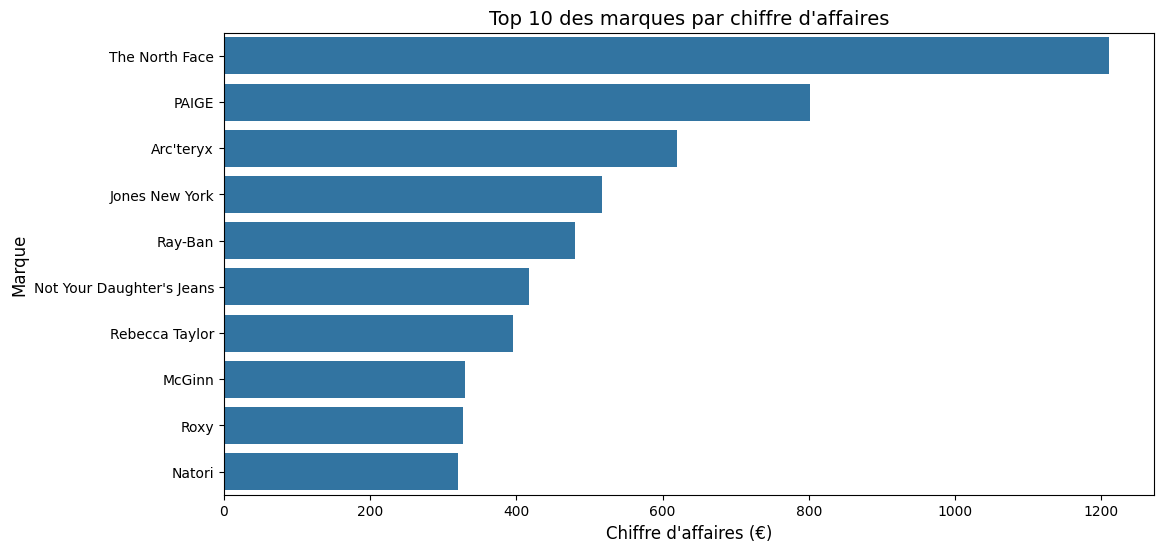

In [119]:
# Taille du graphique
plt.figure(figsize=(12, 6))

# Création du graphique
sns.barplot(
    data=top_brands,
    x="chiffre_affaires",
    y="brand"
)

# Ajout du titre
plt.title("Top 10 des marques par chiffre d'affaires", fontsize=14)

# Ajout des labels des axes
plt.xlabel("Chiffre d'affaires (€)", fontsize=12)
plt.ylabel("Marque", fontsize=12)

# Affichage du graphe
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- La marque **The North Face** génère le chiffre d'affaires le plus élevé avec 1 211 €, soit un niveau nettement supérieur aux autres marques du classement.

- **PAIGE** et **Arc'teryx** complètent le podium avec respectivement 801 € et 620 € de chiffre d'affaires.

- Un écart important est observé entre la première marque et les suivantes, ce qui traduit une concentration des revenus sur un nombre limité de marques.

- Les dix premières marques appartiennent majoritairement à des segments premium ou spécialisés, suggérant une contribution significative des produits à forte valeur ajoutée.

### Interprétation :

- Les marques leaders semblent bénéficier d'un positionnement premium leur permettant de générer davantage de revenus par vente.

- La domination de The North Face indique un poids important dans la génération du chiffre d'affaires global et mérite une analyse plus approfondie (nombre de ventes, prix moyen, marge générée).

- Les performances observées montrent que la valeur des ventes peut être davantage influencée par le prix moyen des produits que par le seul volume de ventes.

### Conclusion :


- L'analyse du Top 10 des marques par chiffre d'affaires révèle une forte contribution de quelques marques premium, avec The North Face comme principal moteur de revenus. Les écarts observés suggèrent que le positionnement produit et le prix moyen jouent un rôle majeur dans la performance commerciale. 

</details

### 5.4 Contribution par catégorie

#### 5.4.1 Identification des catégories les plus présentes

In [120]:
''' 
Ici nous allons identifier les catégories les plus présentes
'''
# Top categorie des produits les plus présents
top_categories = df_sales["category"].value_counts().reset_index()
top_categories.columns = ["category", "nb_ventes"]

# Affichage
top_categories.head(10)

,category,nb_ventes
0,Intimates,72
1,Fashion Hoodies & Sweatshirts,35
2,Sweaters,26
3,Accessories,24
4,Maternity,23
5,Pants & Capris,22
6,Swim,22
7,Tops & Tees,20
8,Sleep & Lounge,20
9,Dresses,19


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- La catégorie Intimates est la plus vendue avec 72 ventes, loin devant Fashion Hoodies & Sweatshirts (35 ventes) et Sweaters (26 ventes). Les catégories Accessories, Maternity, Pants & Capris et Swim présentent également des volumes de ventes relativement élevés.

### Interprétation :

- Les produits de la catégorie Intimates semblent répondre à un besoin récurrent, ce qui favorise une fréquence d'achat plus importante. Les catégories les plus vendues correspondent principalement à des articles du quotidien ou à renouvellement fréquent.

### Conclusion :

- La performance en volume est principalement portée par Intimates, qui constitue un levier important d'acquisition et de fidélisation des clientes. Cette catégorie mérite une attention particulière dans les stratégies promotionnelles et de merchandising.

</details

#### 5.4.2 Calcul du CA par catégorie

In [121]:
# Chiffre d'affaires par catégorie
ca_top_categories = (
    df_sales
    .groupby("category", as_index=False)["sale_price"]
    .sum()
    .rename(columns={"sale_price": "chiffre_affaires"})
    .sort_values(by="chiffre_affaires", ascending=False)
)

# Affichage du top 10
ca_top_categories.head(10)

,category,chiffre_affaires
10,Outerwear & Coats,3147.65
5,Intimates,2259.31
6,Jeans,2023.56
18,Sweaters,1827.21
4,Fashion Hoodies & Sweatshirts,1785.07
3,Dresses,1340.65
19,Swim,1267.04
15,Sleep & Lounge,1257.84
11,Pants & Capris,1225.92
0,Accessories,1046.94


#### 5.4.3 Graphique — Contribution des catégories au CA

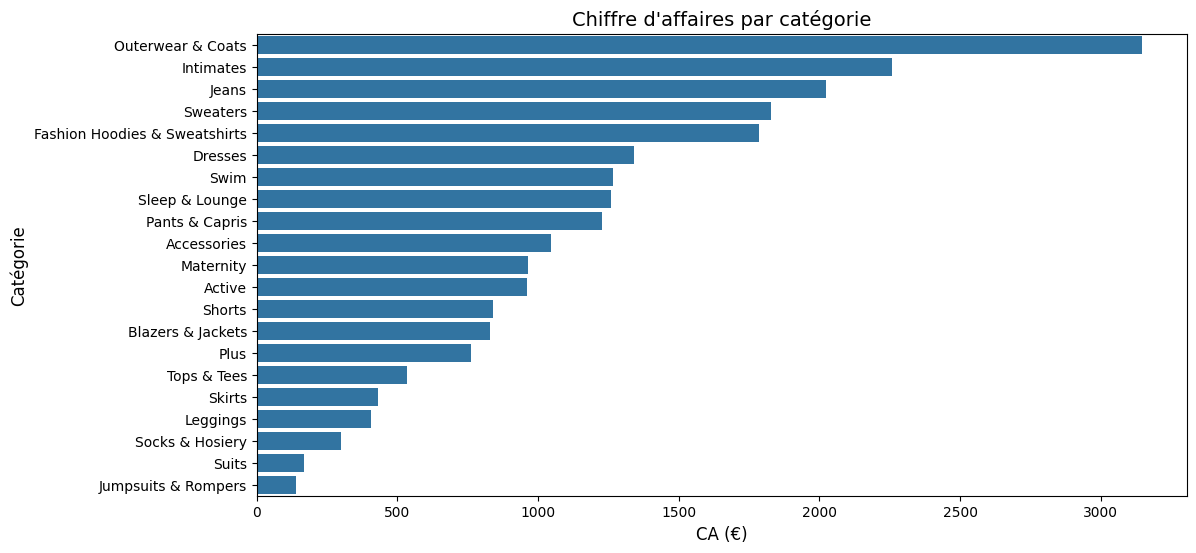

In [122]:
# Création de la taille de la figure 
plt.figure(figsize=(12,6))

# Création du graphieque
sns.barplot(
    data=ca_top_categories,
    x="chiffre_affaires",
    y="category"
)

# Ajout du titre
plt.title("Chiffre d'affaires par catégorie", fontsize=14)

# Ajout des labels des axes
plt.xlabel("CA (€)", fontsize=12)
plt.ylabel("Catégorie", fontsize=12)

# Affichage du graphique
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- La catégorie Outerwear & Coats génère le chiffre d'affaires le plus élevé avec 3 147,65 €, suivie par Intimates (2 259,31 €) et Jeans (2 023,56 €). 

- Certaines catégories comme Jeans ou Outerwear & Coats apparaissent parmi les meilleures en chiffre d'affaires sans être parmi les plus vendues.

### Interprétation :

- Ces résultats suggèrent que les produits de ces catégories possèdent un prix moyen plus élevé. Ainsi, même avec un volume de ventes inférieur, ils contribuent fortement au chiffre d'affaires global.

### Conclusion :

- Le chiffre d'affaires est porté à la fois par des catégories à fort volume (Intimates) et par des catégories à forte valeur unitaire (Outerwear & Coats, Jeans). Une stratégie équilibrée entre volume et valeur est donc essentielle pour maximiser la performance commerciale.

</details

#### 5.4.4 Calcul du prix moyen par catégorie

In [123]:
# Calcul du prix moyen par catégorie
avg_price_category = (
    df_sales
    .groupby("category")["sale_price"]
    .mean()
    .reset_index()
    .rename(columns={"sale_price": "prix_moyen"})
    .sort_values(by="prix_moyen", ascending=False)
)

# Affichage des 10 premières catégories
avg_price_category.head(10)

,category,prix_moyen
10,Outerwear & Coats,224.83
6,Jeans,112.42
2,Blazers & Jackets,92.31
17,Suits,84.03
3,Dresses,70.56
18,Sweaters,70.28
1,Active,68.66
15,Sleep & Lounge,62.89
19,Swim,57.59
11,Pants & Capris,55.72


#### 5.4.5 Graphique — Prix moyen par catégorie

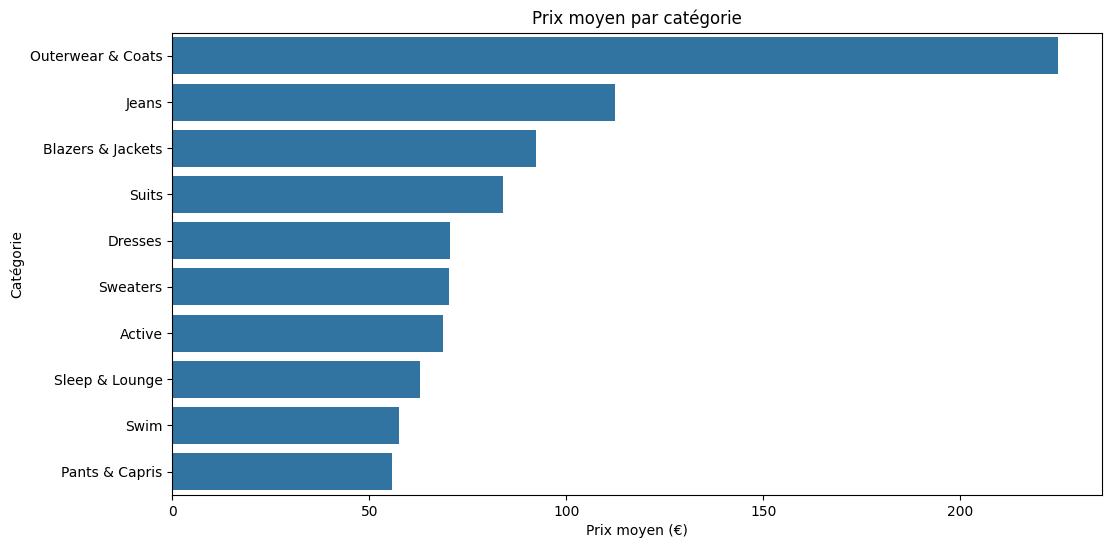

In [124]:
# Taille du graphique
plt.figure(figsize=(12,6))

# Création du graphique
sns.barplot(
    data=avg_price_category.head(10),
    x="prix_moyen",
    y="category"
)

# Ajout du titre
plt.title("Prix moyen par catégorie")

# Ajout des labels des axes
plt.xlabel("Prix moyen (€)")
plt.ylabel("Catégorie")

# Affichage du graphique
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- La catégorie Outerwear & Coats présente le prix moyen le plus élevé (≈225 €).
- Deux dynamiques complémentaires :
  * Catégories premium : fort CA grâce à un prix unitaire élevé.
  * Catégories accessibles : fort CA grâce à un volume de ventes important.

### Interprétation:

- Ces résultats suggèrent que certaines catégories sont positionnées sur des produits plus premium ou à plus forte valeur unitaire.

- La catégorie Outerwear & Coats semble particulièrement orientée vers des articles haut de gamme, ce qui explique son prix moyen très supérieur aux autres catégories.

- À l’inverse, des catégories comme Swim ou Pants & Capris semblent davantage basées sur un volume de ventes plus important avec des prix unitaires plus accessibles.

### Conclusion :

- Le chiffre d’affaires des catégories ne dépend pas uniquement du nombre de ventes réalisées.

- Deux dynamiques complémentaires apparaissent :
  * certaines catégories génèrent du chiffre d’affaires grâce à des prix élevés ;
  * d’autres s’appuient davantage sur le volume de commandes.

- Cette analyse permet de mieux comprendre les mécanismes de performance du catalogue e-commerce.
</details>

### 5.5 Contribution par ville

#### 5.5.1 Calcul du CA par ville

In [125]:
# Calcul du chiffre d'affaires par ville
ca_city = (
    df_sales
    .groupby("city")["sale_price"]
    .sum()
    .reset_index()
    .rename(columns={"sale_price": "chiffre_affaires"})
    .sort_values(by="chiffre_affaires", ascending=False)
)

# Affichage des 10 premières villes
ca_city.head(10)

,city,chiffre_affaires
136,Paris,949.83
108,Locon,903.00
187,Vandœuvre-lès-Nancy,822.96
111,Lyon,536.44
38,Brignoles,509.90
115,Malakoff,436.53
125,Nice,435.40
15,Aubagne,431.89
152,Saint-Chamond,396.42
82,Hasparren,363.92


#### 5.5.2 Graphique — Contribution par ville

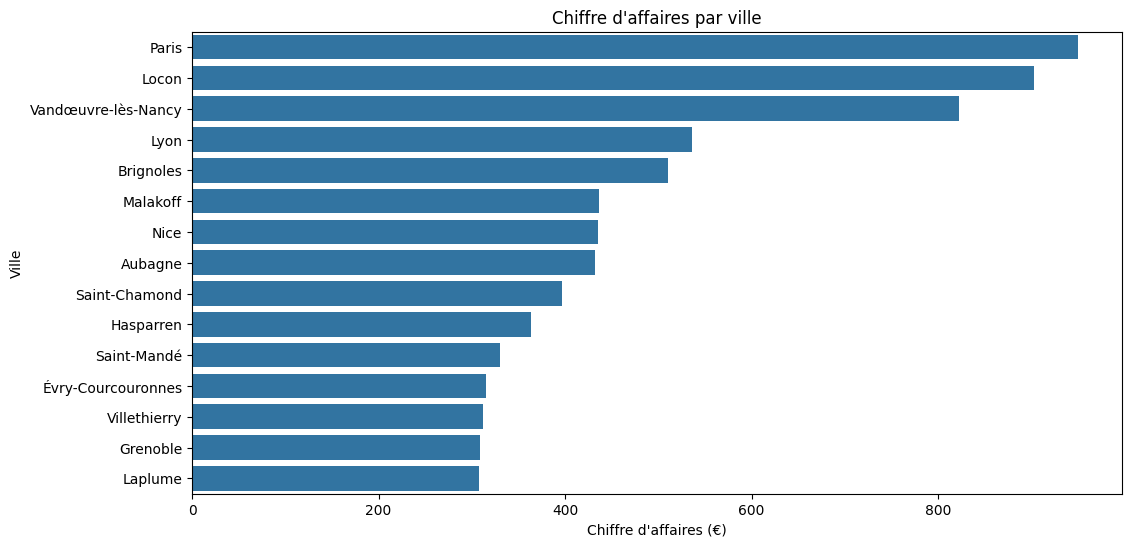

In [126]:
# Taille du graphique
plt.figure(figsize=(12,6))

# Création du graphique
sns.barplot(
    data=ca_city.head(15),
    x="chiffre_affaires",
    y="city"
)

# Ajout du titre
plt.title("Chiffre d'affaires par ville")

# Ajout des labels des axes
plt.xlabel("Chiffre d'affaires (€)")
plt.ylabel("Ville")

# Affichage du graphe
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- Le chiffre d'affaires est inégalement réparti entre les villes. Paris, Locon et Vandœuvre-lès-Nancy sont les villes qui génèrent le plus de revenus, tandis que d'autres villes affichent un chiffre d'affaires plus faible.

### Interprétation :

- Ces écarts peuvent s'expliquer par des différences dans le nombre de clientes, la fréquence des achats ou le montant moyen dépensé par commande. Certaines villes semblent donc contribuer davantage à la performance commerciale que d'autres.

### Conclusion:

- L'analyse met en évidence des zones géographiques plus performantes que d'autres. Ces résultats peuvent aider l'entreprise à identifier les marchés les plus importants et à orienter ses actions marketing pour renforcer sa présence dans les villes à fort potentiel.
</details>

### 5.6 Saisonnalité mensuelle

#### 5.6.1 Calcul du CA par mois

In [127]:
'''
Analyse de la saisonnalité mensuelle :
on calcule le chiffre d'affaires total par mois et par année
afin d'identifier les périodes fortes et faibles des ventes.
On garde uniquement les ventes finalisées ("Complete").
'''

ca_saisonnalite = (
    df_sales
    .groupby(["year", "month"])["sale_price"]
    .sum()
    .reset_index()
)

# Affichage du tableau
ca_saisonnalite

,year,month,sale_price
0,2023,1,379.06
1,2023,2,273.11
2,2023,3,282.14
3,2023,4,743.30
4,2023,5,641.71
5,2023,6,447.30
6,2023,7,384.86
7,2023,8,863.26
8,2023,9,1169.07
9,2023,10,1093.90


#### 5.6.2 Graphique — Saisonnalité du CA (2023 vs 2024)

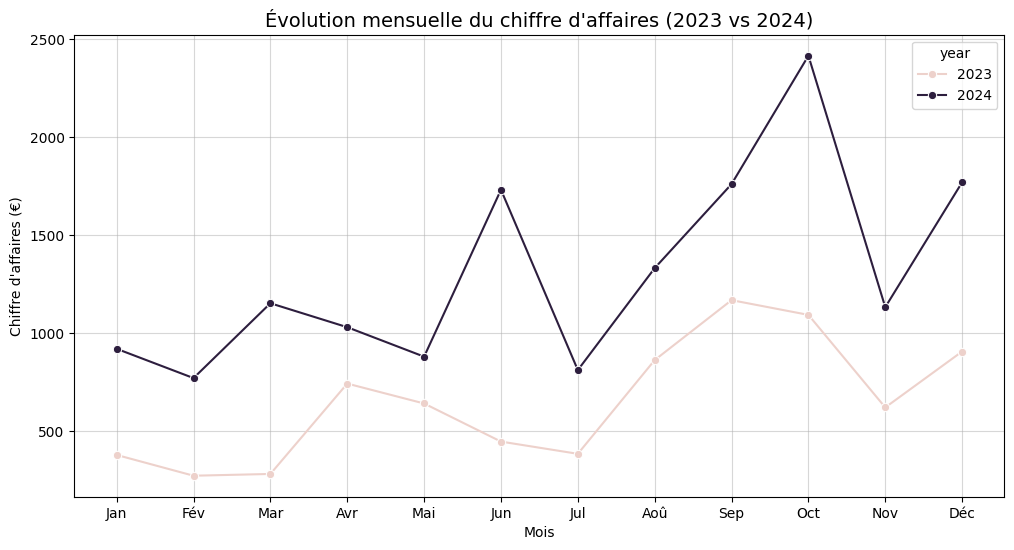

In [128]:
# Conversion des noms des mois en français pour l'axe X
noms_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
             'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']

# Taille du graphique
plt.figure(figsize=(12, 6))

# Création du graphique 
sns.lineplot(
    data=ca_saisonnalite,
    x="month",
    y="sale_price",
    hue="year",
    marker="o"
)

# Ajout du titre
plt.title("Évolution mensuelle du chiffre d'affaires (2023 vs 2024)", fontsize=14)

# Ajout des labels des axes
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires (€)")

# Personnalisation de l'axe X avec les noms des mois
plt.xticks(ticks=range(1, 13), labels=noms_mois)

# Ajout d'une grille pour améliorer la lisibilité
plt.grid(True, linestyle='-', alpha=0.5)

# Affichage du graphe
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- Le chiffre d'affaires est systématiquement plus élevé en 2024 qu'en 2023, ce qui traduit une amélioration globale des performances commerciales.
- Les mois de septembre, octobre et décembre enregistrent les niveaux de chiffre d'affaires les plus élevés sur la période étudiée.
- Octobre 2024 constitue le pic de chiffre d'affaires de l'ensemble du périmètre analysé.
- Le premier trimestre (janvier à mars) affiche des résultats plus faibles, particulièrement en 2023.
- Une forte progression du chiffre d'affaires est observée au second semestre 2024.

### Interprétation :

- La hausse observée en 2024 peut s'expliquer par une augmentation du nombre de commandes, du panier moyen ou une meilleure performance commerciale globale.
- Les pics de septembre à décembre suggèrent un effet de saisonnalité lié à la rentrée, aux promotions d'automne et aux achats de fin d'année.
- Le second semestre semble être la période la plus favorable pour l'activité e-commerce.

### Conclusion :

- L'année 2024 surperforme nettement l'année 2023 sur l'ensemble des mois analysés.
- Les mois de septembre à décembre représentent les périodes les plus stratégiques pour le chiffre d'affaires.
- Ces résultats suggèrent que les futures actions marketing et commerciales devraient être renforcées sur le second semestre afin de maximiser les revenus.

</details>

# 6. Comparaison 2023 vs 2024

### 6.1 Chiffre d'affaires annuel 2023 vs 2024

In [129]:
'''
Objectif :
Mesurer les performances entre 2023 et 2024
à travers le chiffre d'affaires (CA)
et identifier les écarts de performance.
'''

# Calcul du chiffre d'affaires annuel
ca_year = (
    df_sales
    .groupby("year")["sale_price"]
    .sum()
    .reset_index()
    .rename(columns={"sale_price": "CA"})
)

# Affichage
ca_year

,year,CA
0,2023,7806.32
1,2024,15716.28


### 6.2 Graphique — CA annuel avec écart 2023 vs 2024

CA 2023       : 7806.32 €
CA 2024       : 15716.28 €
Écart absolu  : 7909.96 €
Écart relatif : 101.33 %


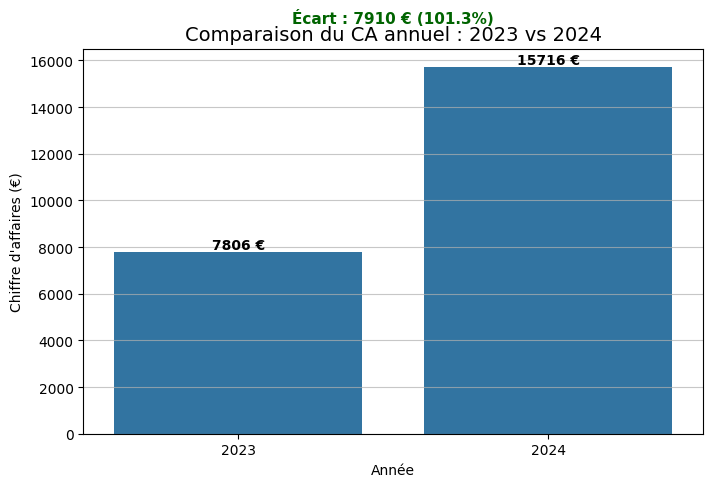

In [130]:
# Calcul des écarts
ca_2023 = ca_year.loc[ca_year["year"] == 2023, "CA"].values[0]
ca_2024 = ca_year.loc[ca_year["year"] == 2024, "CA"].values[0]

ecart_abs      = ca_2024 - ca_2023
ecart_relatif  = (ecart_abs / ca_2023) * 100

# Affichage texte
print(f"CA 2023       : {ca_2023:.2f} €")
print(f"CA 2024       : {ca_2024:.2f} €")
print(f"Écart absolu  : {ecart_abs:.2f} €")
print(f"Écart relatif : {ecart_relatif:.2f} %")

# Taille du graphique
plt.figure(figsize=(8, 5))

# Création du graphe
sns.barplot(data=ca_year, x="year", y="CA")

# Ajout du titre
plt.title("Comparaison du CA annuel : 2023 vs 2024", fontsize=14)

# Ajout des labels des axes
plt.xlabel("Année")
plt.ylabel("Chiffre d'affaires (€)")

# Valeurs sur les barres
for index, row in ca_year.iterrows():
    plt.text(
        index,
        row["CA"],
        f"{row['CA']:.0f} €",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# Annotation de l'écart sur le graphique
plt.text(
    0.5,
    max(ca_year["CA"]) * 1.12,
    f"Écart : {ecart_abs:.0f} € ({ecart_relatif:.1f}%)",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="darkgreen"
)

# Ajout d'une grille pour améliorer la lisibilité
plt.grid(axis="y", linestyle="-", alpha=0.7)

# Affichage du graphe
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- Le chiffre d'affaires du périmètre France × Women est passé de 7 806 € en 2023 à 15 716 € en 2024, soit une augmentation de 7 910 € (+101,3 %). 
- L'activité a donc plus que doublé sur la période étudiée.

### Interprétation :

- Cette forte progression traduit une amélioration significative de la performance commerciale en 2024. Elle peut s'expliquer par une augmentation du nombre de commandes, une hausse du panier moyen ou une meilleure contribution de certaines catégories et marques. Cette évolution témoigne d'une dynamique de croissance particulièrement favorable sur le segment étudié.

### Conclusion :

- L'année 2024 marque une nette accélération de l'activité e-commerce du département Women en France.
- La croissance observée constitue un signal positif pour l'entreprise, mais devra être analysée conjointement avec la marge, le taux de retour et les indicateurs clients afin de confirmer qu'elle s'accompagne d'une amélioration durable de la rentabilité et de la performance globale.

</details>

### 6.3 Marge brute annuelle 2023 vs 2024

In [131]:
# Calcul de la marge par ligne
df_sales["marge"] = df_sales["sale_price"] - df_sales["cost"]

# Calcul de la marge brute annuelle
marge_year = (
    df_sales
    .groupby("year")["marge"]
    .sum()
    .reset_index()
    .rename(columns={"marge": "marge_brute"})
)

# Écarts marge
marge_2023     = marge_year.loc[marge_year["year"] == 2023, "marge_brute"].values[0]
marge_2024     = marge_year.loc[marge_year["year"] == 2024, "marge_brute"].values[0]
ecart_marge    = marge_2024 - marge_2023
ecart_marge_pc = (ecart_marge / marge_2023) * 100

# Affichage
print(f"Marge brute 2023 : {marge_2023:.2f} €")
print(f"Marge brute 2024 : {marge_2024:.2f} €")
print(f"Écart absolu     : {ecart_marge:.2f} €")
print(f"Écart relatif    : {ecart_marge_pc:.2f} %")

Marge brute 2023 : 4075.34 €
Marge brute 2024 : 8134.61 €
Écart absolu     : 4059.26 €
Écart relatif    : 99.61 %


### 6.4 Taux de retour annuel 2023 vs 2024

In [132]:
# Année 2023
df_2023 = df_clean[df_clean["year"] == 2023]

total_2023 = len(
    df_2023[
        (df_2023["item_status"] == "Complete") |
        (df_2023["item_status"] == "Returned")
    ]
)

retours_2023 = len(df_2023[df_2023["item_status"] == "Returned"])

taux_retour_2023 = (retours_2023 / total_2023) * 100

# Affichage
print(f"Taux de retour 2023 : {taux_retour_2023:.2f} %")


# Année 2024
df_2024 = df_clean[df_clean["year"] == 2024]

total_2024 = len(
    df_2024[
        (df_2024["item_status"] == "Complete") |
        (df_2024["item_status"] == "Returned")
    ]
)

retours_2024 = len(df_2024[df_2024["item_status"] == "Returned"])

taux_retour_2024 = (retours_2024 / total_2024) * 100

# Affichage
print(f"Taux de retour 2024 : {taux_retour_2024:.2f} %")

Taux de retour 2023 : 37.87 %
Taux de retour 2024 : 30.42 %


### 6.5 Tableau récapitulatif des KPI 2023 vs 2024

In [133]:
# Calcul du panier moyen par année
ca_par_annee = df_sales.groupby("year")["sale_price"].sum()
nb_commandes_par_annee = df_sales.groupby("year")["order_id"].nunique()

panier_year = (
    (ca_par_annee / nb_commandes_par_annee)
    .reset_index(name="panier_moyen")
)

# Récupération des valeurs
panier_2023 = panier_year.loc[panier_year["year"] == 2023, "panier_moyen"].iloc[0]
panier_2024 = panier_year.loc[panier_year["year"] == 2024, "panier_moyen"].iloc[0]

# Tableau récapitulatif
recap = pd.DataFrame({
    "KPI": [
        "CA (€)",
        "Marge brute (€)",
        "Taux de retour (%)",
        "Panier moyen (€)"
    ],
    "2023": [
        round(ca_2023, 2),
        round(marge_2023, 2),
        round(taux_retour_2023, 2),
        round(panier_2023, 2)
    ],
    "2024": [
        round(ca_2024, 2),
        round(marge_2024, 2),
        round(taux_retour_2024, 2),
        round(panier_2024, 2)
    ]
})

# Calcul de l'évolution entre 2023 et 2024
recap["Écart (%)"] = (
    (recap["2024"] - recap["2023"])
    / recap["2023"]
    * 100
).round(2)

# Affichage
print(recap)

                  KPI     2023      2024  Écart (%)
0              CA (€)  7806.32  15716.28     101.33
1     Marge brute (€)  4075.34   8134.61      99.61
2  Taux de retour (%)    37.87     30.42     -19.67
3    Panier moyen (€)    80.48     85.41       6.13


# 7. Calcul des KPI

### 7.1 KPI — Chiffre d'affaires (CA)

In [134]:
# Calcul du CA global (toutes années confondues)
ca_global = df_sales["sale_price"].sum()
print(f"Chiffre d'affaires global (2023+2024) : {ca_global:.2f} €")

print()

# Calcul du CA par année (2023 & 2024)
ca_par_annee = df_sales.groupby("year")["sale_price"].sum()

# Affichage
print("Chiffre d'affaires par année :")
print(ca_par_annee)

Chiffre d'affaires global (2023+2024) : 23522.60 €

Chiffre d'affaires par année :
year
2023     7806.32
2024    15716.28
Name: sale_price, dtype: float64


### 7.2 KPI — Marge brute

In [135]:
# Calcul de la marge brute globale
marge_brute_global = df_sales["marge"].sum()
print(f"Marge brute globale (2023+2024) : {marge_brute_global:.2f} €")

print()

# Calcul de la marge brute par année (2023 & 2024)
marge_par_annee = df_sales.groupby("year")["marge"].sum()

# Affichage
print("Marge brute par année :")
print(marge_par_annee)

Marge brute globale (2023+2024) : 12209.95 €

Marge brute par année :
year
2023    4075.34
2024    8134.61
Name: marge, dtype: float64


### 7.3 KPI — Panier moyen

In [136]:
# Calcul du chiffre d'affaires par année
ca_par_annee = df_sales.groupby("year")["sale_price"].sum()

# Calcul du nombre de commandes distinctes par année
nb_commandes_par_annee = df_sales.groupby("year")["order_id"].nunique()

# Calcul du panier moyen
panier_moyen_par_annee = (
    ca_par_annee / nb_commandes_par_annee
).reset_index()

# Renommer la colonne
panier_moyen_par_annee.columns = ["year", "panier_moyen"]

# Affichage
print(panier_moyen_par_annee)

   year  panier_moyen
0  2023         80.48
1  2024         85.41


### 7.4 KPI — Taux de retour

In [137]:
# Nombre de lignes retournées
retours = df_clean[df_clean["item_status"] == "Returned"]
nb_retours = len(retours)

# Nombre de ventes + retours (sur df_clean)
ventes_retours = df_clean[
    df_clean["item_status"].isin(["Complete", "Returned"])
]
nb_total = len(ventes_retours)

# Calcul du taux de retour global
taux_retour_global = (nb_retours / nb_total) * 100

# Affichage
print(f"Nombre de retours  : {nb_retours}")
print(f"Nombre total (ventes + retours) : {nb_total}")
print(f"Taux de retour global : {taux_retour_global:.2f} %")

print()

# Taux de retour par année
print("Taux de retour par année :")
print(f"  2023 : {taux_retour_2023:.2f} %")
print(f"  2024 : {taux_retour_2024:.2f} %")

Nombre de retours  : 211
Nombre total (ventes + retours) : 636
Taux de retour global : 33.18 %

Taux de retour par année :
  2023 : 37.87 %
  2024 : 30.42 %


### 7.5 KPI — Taux de ré-achat

In [138]:
# Taux de ré-achat 2023

# Clients ayant commandé en 2023
df_2023 = df_sales[df_sales["year"] == 2023]

# Nombre de commandes par client
commandes_2023 = df_2023.groupby("user_id")["order_id"].nunique()

# Nombre de clients ayant passé au moins 2 commandes
clients_reachat_2023 = (commandes_2023 >= 2).sum()

# Nombre total de clients
total_clients_2023 = commandes_2023.count()

# Taux de ré-achat
taux_reachat_2023 = clients_reachat_2023 / total_clients_2023 * 100


# Taux de ré-achat 2024 

df_2024 = df_sales[df_sales["year"] == 2024]

commandes_2024 = df_2024.groupby("user_id")["order_id"].nunique()

clients_reachat_2024 = (commandes_2024 >= 2).sum()

total_clients_2024 = commandes_2024.count()

taux_reachat_2024 = clients_reachat_2024 / total_clients_2024 * 100


# Affichage
print("Taux de ré-achat 2023 :", round(taux_reachat_2023, 2), "%")
print("Taux de ré-achat 2024 :", round(taux_reachat_2024, 2), "%")

Taux de ré-achat 2023 : 0.0 %
Taux de ré-achat 2024 : 3.39 %


### 7.6 Tableau récapitulatif final — tous les KPI

In [139]:
# Calcul des écarts (%)

ecart_ca = (ca_2024 - ca_2023) / ca_2023 * 100

ecart_marge = (marge_2024 - marge_2023) / marge_2023 * 100

ecart_panier = (panier_2024 - panier_2023) / panier_2023 * 100

ecart_retour = (taux_retour_2024 - taux_retour_2023) / taux_retour_2023 * 100

# Gestion du cas où le taux de ré-achat 2023 est égal à 0
if taux_reachat_2023 == 0:
    ecart_reachat = None
else:
    ecart_reachat = (
        (taux_reachat_2024 - taux_reachat_2023)
        / taux_reachat_2023
        * 100
    )

# Création du tableau récapitulatif
recap_final = pd.DataFrame({
    "KPI": [
        "CA (€)",
        "Marge brute (€)",
        "Panier moyen (€)",
        "Taux de retour (%)",
        "Taux de ré-achat (%)"
    ],
    "2023": [
        ca_2023,
        marge_2023,
        panier_2023,
        taux_retour_2023,
        taux_reachat_2023
    ],
    "2024": [
        ca_2024,
        marge_2024,
        panier_2024,
        taux_retour_2024,
        taux_reachat_2024
    ],
    "Écart (%)": [
        ecart_ca,
        ecart_marge,
        ecart_panier,
        ecart_retour,
        ecart_reachat
    ]
})

# Affichage
recap_final

,KPI,2023,2024,Écart (%)
0,CA (€),7806.32,15716.28,101.33
1,Marge brute (€),4075.34,8134.61,99.61
2,Panier moyen (€),80.48,85.41,6.13
3,Taux de retour (%),37.87,30.42,-19.67
4,Taux de ré-achat (%),0.00,3.39,NaN


# 8. Recommandations Business

### 8.1 Principaux constats

In [140]:
print("RÉCAPITULATIF DES KPI")

print("\n--- Chiffre d'affaires ---")
print(f"CA 2023 : {ca_2023:.2f}")
print(f"CA 2024 : {ca_2024:.2f}")
print(f"Évolution : {ecart_ca:.2f} %")

print("\n--- Marge brute ---")
print(f"Marge 2023 : {marge_2023:.2f}")
print(f"Marge 2024 : {marge_2024:.2f}")
print(f"Évolution : {ecart_marge:.2f} %")

print("\n--- Taux de retour ---")
print(f"2023 : {taux_retour_2023:.2f} %")
print(f"2024 : {taux_retour_2024:.2f} %")

print("\n--- Taux de ré-achat ---")
print(f"2023 : {taux_reachat_2023:.2f} %")
print(f"2024 : {taux_reachat_2024:.2f} %")

RÉCAPITULATIF DES KPI

--- Chiffre d'affaires ---
CA 2023 : 7806.32
CA 2024 : 15716.28
Évolution : 101.33 %

--- Marge brute ---
Marge 2023 : 4075.34
Marge 2024 : 8134.61
Évolution : 99.61 %

--- Taux de retour ---
2023 : 37.87 %
2024 : 30.42 %

--- Taux de ré-achat ---
2023 : 0.00 %
2024 : 3.39 %


### 8.2 Recommandations Business

**Recommandation 1 — Renforcer les catégories premium à forte marge**

- La catégorie Outerwear & Coats génère le prix moyen le plus élevé (≈225 €) et contribue fortement au CA. Mettre en avant ces catégories dans les campagnes marketing permet d'optimiser le chiffre d'affaires sans augmenter le volume de commandes.

**Recommandation 2 — Capitaliser sur la saisonnalité**

- Octobre, septembre et décembre sont les mois les plus performants et représente des périodes clés. Il est recommandé d’anticiper les campagnes promotionnelles dès la fin de l’été pour maximiser le CA sur le second semestre.

**Recommandation 3 — Analyser et réduire le taux de retour**

- Le taux de retour est un indicateur de satisfaction client et de coût opérationnel. Identifier les catégories avec le taux de retour le plus élevé permet de cibler les améliorations (photos produit, descriptions, guide des tailles).

**Recommandation 4 — Améliorer la fidélisation client** 

- Le taux de ré-achat est calculable par année. Si ce taux est faible, la mise en place d'un programme CRM (email post-achat, offres personnalisées) peut significativement augmenter la part des clients revenant acheter une seconde fois.

### 8.3 Conclusion générale

L’analyse met en évidence une **forte croissance de l’activité entre 2023 et 2024**, accompagnée d’une amélioration des indicateurs de performance (CA, marge, retours).  
Les principaux leviers d’optimisation se situent désormais sur la **fidélisation client, la réduction des retours et la valorisation des catégories premium**.

# 9. Export des données propres


In [141]:
# Exporter le DataFrame nettoyé
df_clean.to_csv('Thelook_women_nettoyes.csv', index=False, encoding='utf-8')   

# Affichage
print("Export réussi : thelook_women_nettoyes.csv")
print(f"Dimensions exportées : {df_clean.shape[0]} lignes x {df_clean.shape[1]} colonnes")

Export réussi : thelook_women_nettoyes.csv
Dimensions exportées : 1679 lignes x 22 colonnes
